In [3]:
#Task:1....Date:9-04-2026
# Titanic Data Cleaning & Preprocessing



In [4]:
# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
plt.style.use('ggplot')

In [5]:
## Step 1: Load the Dataset

In [7]:
# Loading dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Preview first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
## Step 2: Initial Data Exploration
#Understanding structure, data types and missing values

In [10]:
# Basic info
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         

In [11]:
## Step 3: Handling Missing Values
##Filling missing values using statistical methods

In [12]:
# Filling 'Age' with median
#using median + dropping Cabin

df['Age'] = df['Age'].fillna(df['Age'].median())

# Filling 'Embarked' with most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Dropping Cabin column (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [13]:
## Step 4: Encoding Categorical Features
##Converting text data into numerical form

In [14]:
##using:drop_first=True (avoids dummy variable trap)
from sklearn.preprocessing import LabelEncoder

# Encoding 'Sex'
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])

# One-hot encoding for 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True


In [16]:
##Step 5: Feature Scaling
#Standardizing numerical features for better model performance

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaling selected columns
cols_to_scale = ['Age', 'Fare']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.663861,1,0,PC 17599,0.786845,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,False,True
4,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,False,True


In [18]:
##Step 6: Outlier Detection
##Using boxplot to visualize extreme values

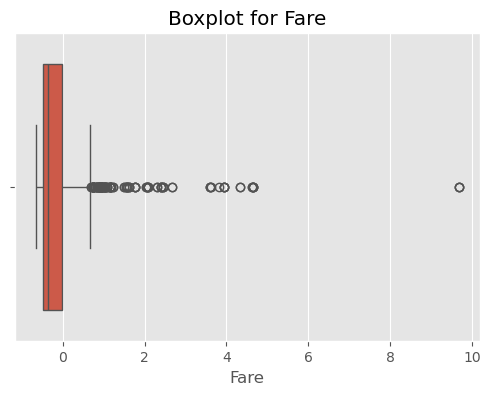

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot for Fare")
plt.show()

In [20]:
##Step 7: Removing Outliers using IQR Method

In [21]:
# IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering dataset
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

print("Outliers removed successfully!")

Outliers removed successfully!


In [22]:
##Step 8: Final Cleaned Dataset

In [23]:
df.head()

print("\nFinal Shape of Dataset:", df.shape)


Final Shape of Dataset: (775, 12)
